In [ ]:
pip install geopandas

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [8]:
# Caminho do shapefile (.shp)
shapefile_path = "/home/ifmt-aluno/Downloads/Mapas/"

# Coordenadas do ponto
latitude = -15.889807455302577
longitude = -52.2610842638621

In [10]:
gdf = gpd.read_file(shapefile_path)

#Verifica e ajusta o CRS, se necessário
if gdf.crs is None:
    raise ValueError("O shapefile não possui CRS definido.")

#Cria o ponto em WGS84 (EPSG:4326)
ponto = gpd.GeoDataFrame(
    {"nome": ["Ponto de Interesse"]},
    geometry=[Point(longitude, latitude)],
    crs="EPSG:4326"
)

#Reprojeta o ponto para o mesmo CRS do shapefile,se necessário
if gdf.crs != ponto.crs:
    ponto = ponto.to_crs(gdf.crs)

Text(80.34722222222221, 0.5, 'Latitude')

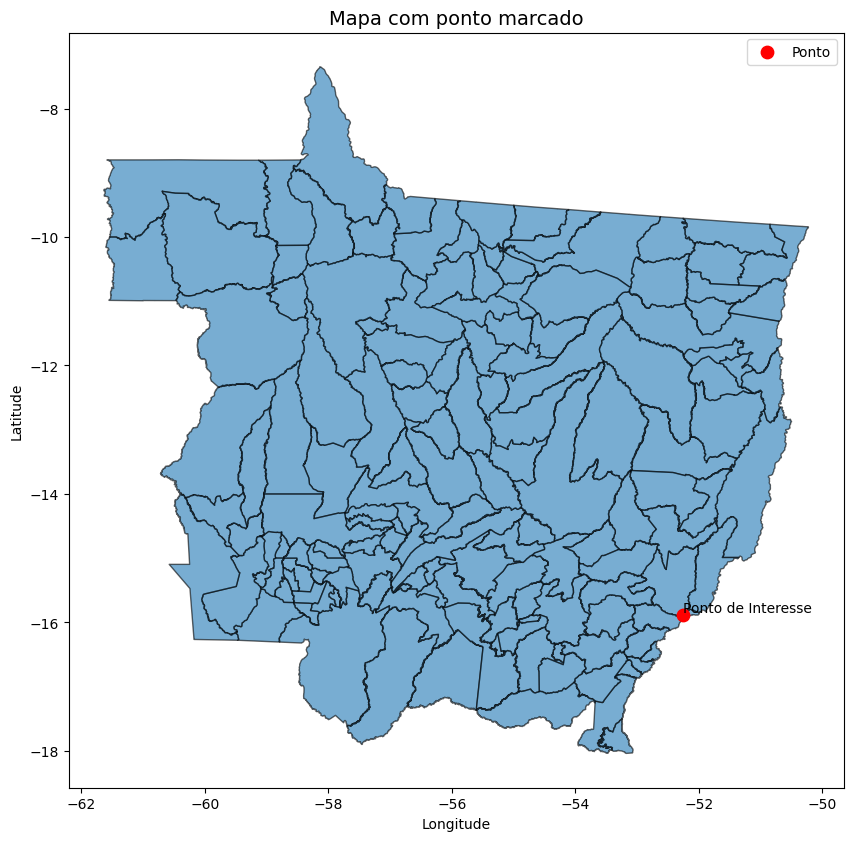

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

#Plota o shapefile
gdf.plot(ax=ax, edgecolor="black", alpha=0.6)

#Plota o ponto
ponto.plot(ax=ax, marker="o", markersize=80, color="red", label="Ponto")

#Adiciona rótulo ao ponto
x = ponto.geometry.iloc[0].x
y = ponto.geometry.iloc[0].y
ax.text(x, y, "Ponto de Interesse", fontsize=10, verticalalignment="bottom")

# título e Legenda
ax.set_title("Mapa com ponto marcado", fontsize=14)
ax.legend()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [14]:
gdf_BAG = gdf[gdf['NM_MUN']=='Barra do Garças']
#Reprojeta o ponto para o mesmo CRS do shapefile, se necessário

<Axes: >

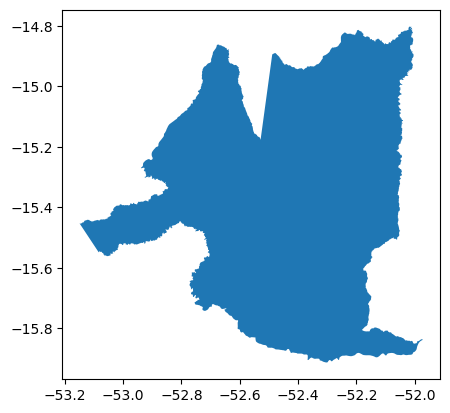

In [15]:
gdf_BAG.plot()